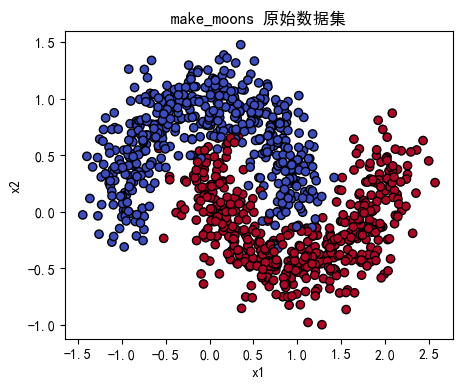

训练集：(600, 2), 验证集：(200, 2), 测试集：(200, 2)
Epoch    0| Train Loss:0.644,Acc0.707|Val Loss:0.645,Acc:0.675
Epoch  100| Train Loss:0.495,Acc0.790|Val Loss:0.502,Acc:0.780
Epoch  200| Train Loss:0.398,Acc0.820|Val Loss:0.415,Acc:0.805
Epoch  300| Train Loss:0.347,Acc0.833|Val Loss:0.372,Acc:0.815
Epoch  400| Train Loss:0.314,Acc0.848|Val Loss:0.346,Acc:0.835
Epoch  500| Train Loss:0.290,Acc0.865|Val Loss:0.328,Acc:0.840
Epoch  600| Train Loss:0.274,Acc0.878|Val Loss:0.317,Acc:0.855
Epoch  700| Train Loss:0.262,Acc0.882|Val Loss:0.307,Acc:0.855


C:\Users\17001\AppData\Local\Temp\ipykernel_17036\462480564.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_load.load_state_dict(torch.load("mlp_moon.pth"))


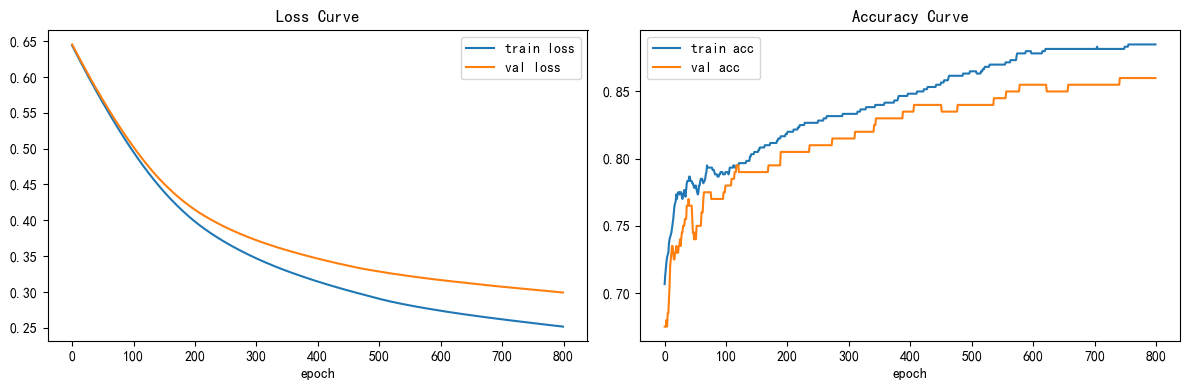

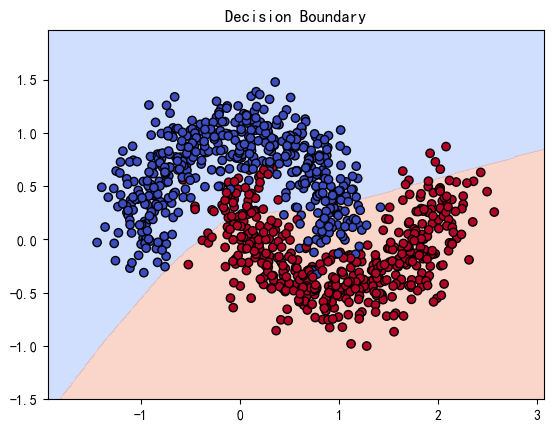

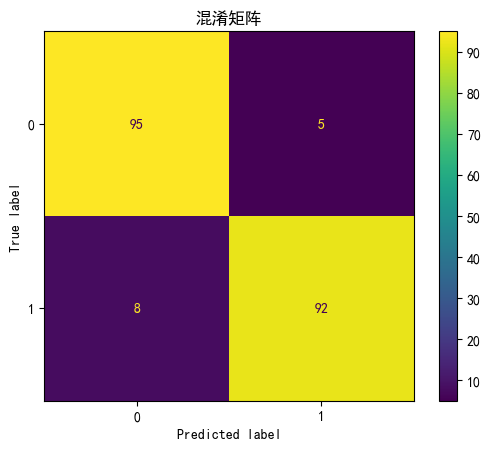

测试集错误样本数量：13
训练耗时:1.06秒


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

X,y = make_moons(n_samples=1000, noise=0.2, random_state=seed)
plt.figure(figsize=(5,4))
plt.scatter(X[:,0],X[:,1],c=y, cmap="coolwarm", edgecolors="k")
plt.title("make_moons 原始数据集")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

X_trainval,X_test,y_trainval,y_test = train_test_split(X,y,test_size=0.2,random_state=seed,stratify=y)
X_train,X_val,y_train,y_val = train_test_split(X_trainval,y_trainval,test_size=0.25,random_state=seed,stratify=y_trainval)
print(f"训练集：{X_train.shape}, 验证集：{X_val.shape}, 测试集：{X_test.shape}")
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(hidden_dim=16)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

start_time = time.time()
epochs = 800
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred_logit = model(X_train)
    loss_train = criterion(y_pred_logit, y_train)
    loss_train.backward()
    optimizer.step()

    
    y_pred_train = (torch.sigmoid(y_pred_logit) > 0.5).float()
    acc_train = (y_pred_train == y_train).sum() / len(y_train)

    model.eval()
    with torch.no_grad():
        y_pred_val_logit = model(X_val)
        loss_val = criterion(y_pred_val_logit, y_val)
        y_pred_val = (torch.sigmoid(y_pred_val_logit) > 0.5).float()
        acc_val = (y_pred_val == y_val).sum() / len(y_val)

        train_loss_list.append(loss_train.item())
        val_loss_list.append(loss_val.item())
        train_acc_list.append(acc_train.item())
        val_acc_list.append(acc_val.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d}| Train Loss:{loss_train:.3f},Acc{acc_train:.3f}|Val Loss:{loss_val:.3f},Acc:{acc_val:.3f}")

torch.save(model.state_dict(), "mlp_moon.pth")
model_load = MLP()
model_load.load_state_dict(torch.load("mlp_moon.pth"))

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(train_loss_list,label="train loss")
axes[0].plot(val_loss_list, label="val loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].set_xlabel("epoch")

axes[1].plot(train_acc_list, label="train acc")
axes[1].plot(val_acc_list, label="val acc")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

def plot_decision_boundary(model,X,y):
    x_min, x_max = X[:,0].min()-0.5,X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5,X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max,0.01))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(grid))>0.5
    pred = pred.reshape(xx.shape).numpy()
    plt.contourf(xx, yy, pred, alpha=0.4, cmap="coolwarm")
    plt.scatter(X[:,0],X[:,1], c=y, cmap="coolwarm", edgecolors="k")
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model, X, y)

model.eval()
with torch.no_grad():
    y_test_logit = model(X_test)
    y_test_pred = (torch.sigmoid(y_test_logit) > 0.5).float()

y_true_np = y_test.numpy().astype(int)
y_pred_np = y_test_pred.numpy().astype(int)

cm = confusion_matrix(y_true_np, y_pred_np)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("混淆矩阵")
plt.show()

wrong_idx = np.where(y_true_np != y_pred_np)[0]
print(f"测试集错误样本数量：{len(wrong_idx)}")
print(f"训练耗时:{time.time() - start_time:.2f}秒")